In [1]:
# pip install ipympl mpl-interactions
# pip install ipympl mpl-interactions
#https://github.com/lyeoni/pytorch-mnist-VAE
#https://github.com/sssingh/mnist-digit-generation-gan/blob/master/mnist_gan.ipynb
# prerequisites
import torch
th = torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.autograd import Variable
from torchvision.utils import save_image

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader

def load_mnist(path, kind='train'):
    import os
    import gzip
    import numpy as np

    """Load MNIST data from `path`"""
    labels_path = os.path.join(path,
                               '%s-labels-idx1-ubyte.gz'
                               % kind)
    images_path = os.path.join(path,
                               '%s-images-idx3-ubyte.gz'
                               % kind)

    with gzip.open(labels_path, 'rb') as lbpath:
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8,
                               offset=8)

    with gzip.open(images_path, 'rb') as imgpath:
        images = np.frombuffer(imgpath.read(), dtype=np.uint8,
                               offset=16).reshape(len(labels), 784)

    return images, labels
    
class ArrayToDataset(Dataset):
    def __init__(self, data, targets, transform=None):
        data = data.reshape((-1,)+(int(X_train.shape[-1]**0.5),)*2)
        self.data = torch.tensor(data/256.0)
        self.targets = targets
        self.transform = transform
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        image = self.data[idx].unsqueeze(0).to(th.float32)
        label = self.targets[idx]
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# Load Dataset

In [6]:
dataset_name = 'fashion'
bs = 100
if dataset_name == 'fashion':
    X_train, y_train = load_mnist('../../Data/fashion', kind='train')
    X_test, y_test = load_mnist('../../Data/fashion', kind='t10k')
    train_dataset = ArrayToDataset(X_train, y_train)
    test_dataset = ArrayToDataset(X_test, y_test)
if dataset_name == 'mnist':
    test_dataset = datasets.MNIST(root='../../Data/', train=False, transform=transforms.ToTensor(), download=False)
    train_dataset = datasets.MNIST(root='../../Data/', train=True, transform=transforms.ToTensor(), download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=bs, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=bs, shuffle=False)

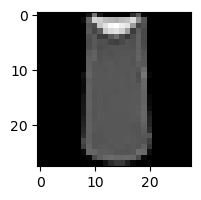

In [7]:
import numpy as np
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(2,2))
plt.imshow(train_dataset[2][0].numpy().reshape(28,28), cmap='gray')
plt.show()

# [[ VAE APPROACH ]]

# Build Model Parts

## Main Model Architecture

In [8]:
# this creates the model
class VAE(nn.Module):
    def __init__(self, x_dim, h_dim1, h_dim2, z_dim):
        super(VAE, self).__init__()
        
        # encoder part
        self.fc1 = nn.Linear(x_dim, h_dim1)
        self.fc2 = nn.Linear(h_dim1, h_dim2)
        self.fc31 = nn.Linear(h_dim2, z_dim)
        self.fc32 = nn.Linear(h_dim2, z_dim)
        # decoder part
        self.fc4 = nn.Linear(z_dim, h_dim2)
        self.fc5 = nn.Linear(h_dim2, h_dim1)
        self.fc6 = nn.Linear(h_dim1, x_dim)
        
    def encoder(self, x):
        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))
        return self.fc31(h), self.fc32(h) # mu, log_var
    
    def sampling(self, mu, log_var):
        std = torch.exp(0.5*log_var)
        eps = torch.randn_like(std)
        return eps.mul(std).add_(mu) # return z sample
        
    def decoder(self, z):
        h = F.relu(self.fc4(z))
        h = F.relu(self.fc5(h))
        return F.sigmoid(self.fc6(h)) 
    
    def forward(self, x):
        mu, log_var = self.encoder(x.view(-1, 784))
        z = self.sampling(mu, log_var)
        return self.decoder(z), mu, log_var

# build model
z_dim=2
vae = VAE(x_dim=784, h_dim1= 512, h_dim2=256, z_dim=z_dim)
# if torch.cuda.is_available():
#     vae.cuda()

In [9]:
vae

VAE(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc31): Linear(in_features=256, out_features=2, bias=True)
  (fc32): Linear(in_features=256, out_features=2, bias=True)
  (fc4): Linear(in_features=2, out_features=256, bias=True)
  (fc5): Linear(in_features=256, out_features=512, bias=True)
  (fc6): Linear(in_features=512, out_features=784, bias=True)
)

## Loss Function

In [7]:
optimizer = optim.Adam(vae.parameters())
# return reconstruction error + KL divergence losses
def loss_function(recon_x, x, mu, log_var):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return BCE + KLD

## Training Function

In [8]:
def train(epoch):
    vae.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        #data = data.cuda()
        optimizer.zero_grad()
        
        recon_batch, mu, log_var = vae(data)
        loss = loss_function(recon_batch, data, mu, log_var)
        
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item() / len(data)))
    print('====> Epoch: {} Average loss: {:.4f}'.format(epoch, train_loss / len(train_loader.dataset)))

## Evaluation Function

In [9]:
def test():
    vae.eval()
    test_loss= 0
    with torch.no_grad():
        for data, _ in test_loader:
            #data = data.cuda()
            recon, mu, log_var = vae(data)
            
            # sum up batch loss
            test_loss += loss_function(recon, data, mu, log_var).item()
        
    test_loss /= len(test_loader.dataset)
    print('====> Test set loss: {:.4f}'.format(test_loss))

# OPTION #1
## Train model
## or skip and go directly to below to load pretrained model

# Training Process

In [10]:
for epoch in range(1, 20):
    train(epoch)
    test()

Train Epoch: 1 [0/60000 (0%)]	Loss: 545.178516
Train Epoch: 1 [10000/60000 (17%)]	Loss: 288.869551
Train Epoch: 1 [20000/60000 (33%)]	Loss: 271.055586
Train Epoch: 1 [30000/60000 (50%)]	Loss: 278.797852
Train Epoch: 1 [40000/60000 (67%)]	Loss: 268.880391
Train Epoch: 1 [50000/60000 (83%)]	Loss: 275.060469
====> Epoch: 1 Average loss: 286.7545
====> Test set loss: 270.7099
Train Epoch: 2 [0/60000 (0%)]	Loss: 268.766523
Train Epoch: 2 [10000/60000 (17%)]	Loss: 276.077520
Train Epoch: 2 [20000/60000 (33%)]	Loss: 263.592402
Train Epoch: 2 [30000/60000 (50%)]	Loss: 268.382676
Train Epoch: 2 [40000/60000 (67%)]	Loss: 270.700059
Train Epoch: 2 [50000/60000 (83%)]	Loss: 262.064512
====> Epoch: 2 Average loss: 266.8827
====> Test set loss: 266.2584
Train Epoch: 3 [0/60000 (0%)]	Loss: 259.044844
Train Epoch: 3 [10000/60000 (17%)]	Loss: 254.831699
Train Epoch: 3 [20000/60000 (33%)]	Loss: 266.680684
Train Epoch: 3 [30000/60000 (50%)]	Loss: 254.877559
Train Epoch: 3 [40000/60000 (67%)]	Loss: 261.43

In [11]:
#torch.save(vae.state_dict(), 'models/vae_{}.p'.format(dataset_name))

# OPTION #2
## Load pretrained model

In [10]:
vae.load_state_dict(torch.load('models/vae_{}.p'.format(dataset_name)))

<All keys matched successfully>

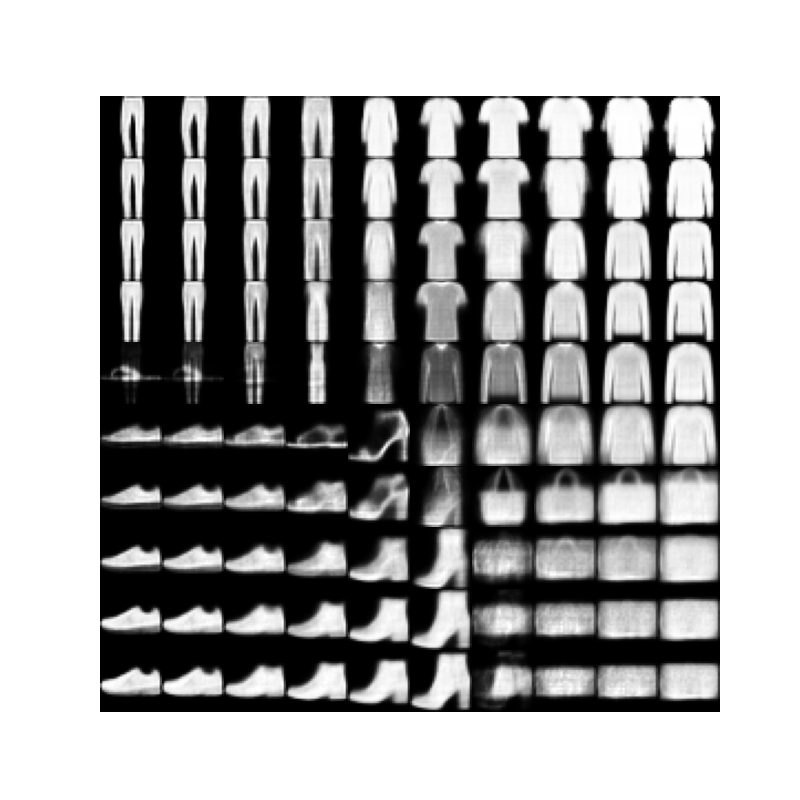

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import torch as th

# Define the grid in the latent space
grid_size = 10
z_range = np.linspace(-2, 2, grid_size)
latent_grid = np.array(np.meshgrid(*(z_range,)*z_dim)).T.reshape(-1, z_dim)
latent_grid[:,2:]=0.

# Generate MNIST images for each point in the grid
generated_images = vae.decoder(th.tensor(latent_grid).to(th.float)).detach().numpy()

# Create a grid of subplots to display the images
fig, axs = plt.subplots(grid_size, grid_size, figsize=(8, 8))
for i in range(grid_size):
    for j in range(grid_size):
        ax = axs[i, j]
        ax.imshow(generated_images[i * grid_size + j].reshape(28, 28), cmap='gray')
        ax.axis('off')

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

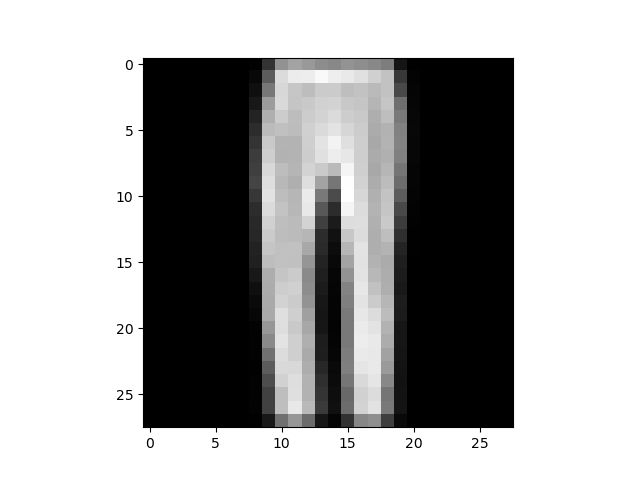

In [16]:
%matplotlib ipympl
import matplotlib.pyplot as plt
import numpy as np

from mpl_interactions import ipyplot as iplt

def f(param1, param2):
    z = torch.tensor([param1,param2]).reshape(1,2).to(torch.float)
    sample = vae.decoder(z).detach()[0].reshape(28,28)
    return sample


fig, ax = plt.subplots()
controls = iplt.imshow(f, param1=(-1, 1), param2=(-1, 1), cmap='gray')